In [ ]:
# Install required libraries
!pip install nltk spacy sentence-transformers umap-learn
!python -m nltk.downloader stopwords
!python -m spacy download en_core_web_sm

# Import libraries
import pandas as pd
import numpy as np
import re
import nltk
import spacy
from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from google.colab import files
from google.colab import output


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 7.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlink-cu1

Cell 2: Loading spaCy & Defining Preprocessing Functions
Summary: In this cell, we load the spaCy language model for tokenization and lemmatization, define stopwords, and initialize the Porter Stemmer. The stopwords are extended to include Hinglish-specific words. The main task here is setting up the tools for text processing that will later be used in the cleaning pipeline.

In [ ]:
# Load spaCy & stopwords
nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words('english'))
hinglish_stopwords = ["ka", "ki", "ke", "hai", "ko", "se", "me", "main", "tha", "thi", "to", "bhi"]
stop_words.update(hinglish_stopwords)
stemmer = PorterStemmer()


Cell 3: Defining Text Normalization Dictionary and Preprocessing Function
Summary: This cell defines a dictionary for slang normalization, replacing offensive or informal terms with more standardized forms. The preprocess_text function cleans the text by removing unwanted characters, stopwords, and applying normalization and stemming/lemmatization processes. It prepares the text data for downstream tasks such as clustering and analysis.

In [ ]:
# Slang normalization dictionary
normalization_dict = {
    "bc": "bhenchod", "bhenchod": "bhenchod", "bhencod": "bhenchod", "benchod": "bhenchod",
    "behnchod": "bhenchod", "mc": "madarchod", "madarchod": "madarchod",
    "chutiya": "chutiya", "chutia": "chutiya", "chutya": "chutiya",
    "gandu": "gandu", "gaandu": "gandu", "harami": "harami",
    "kamine": "kameena", "kameene": "kameena", "kameena": "kameena",
    "saala": "saala", "sala": "saala", "bakchod": "bakchodi", "bakchodi": "bakchodi",
    "kutte": "kutta", "kutti": "kutta", "kutta": "kutta", "jhant": "jhantu",
}

# Preprocessing function
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    doc = nlp(text)
    tokens = []
    for token in doc:
        word = token.text.strip()
        if word and word not in stop_words:
            normalized = normalization_dict.get(word, word)
            lemma = nlp(normalized)[0].lemma_
            stemmed = stemmer.stem(lemma)
            tokens.append(stemmed)
    return ' '.join(tokens)


Cell 4: Uploading CSV and Preprocessing the Text
Summary: This cell handles the file upload where the user provides the dataset (cyberbullying_hinglish_data_4000.csv). It then preprocesses the text by applying the preprocess_text function to the cs_query column, resulting in the cleaned text being stored in a new column clean_text. The dataset shape and a preview of the data are displayed for verification.

In [ ]:
# Upload CSV
print("📥 Please upload your 'cyberbullying_hinglish_data_4000.csv' file:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("\n📊 Dataset Shape:", df.shape)
print("📌 Sample Statements:")
print(df['cs_query'].head())

# Fixed number of clusters
num_clusters = 3
print(f"\n🔢 Using {num_clusters} clusters: Vulgar, Neutral, Positive")

# Preprocess text
df['clean_text'] = df['cs_query'].apply(preprocess_text)


📥 Please upload your 'cyberbullying_hinglish_data_4000.csv' file:


Saving cyberbullying_hinglish_data_4000.csv to cyberbullying_hinglish_data_4000.csv

📊 Dataset Shape: (4000, 1)
📌 Sample Statements:
0    Sameer ka ye video shandaar hai, challenge kar...
1     Nisha shaam se fattu ka ban gaya, text karo usko
2         Ye Rohit classmate apni work me hai, hass do
3    Manish tu toh superb hai, saali kyun ban raha ...
4    Ye Arjun ka profile itna kamchor hai ki ignore...
Name: cs_query, dtype: object

🔢 Using 3 clusters: Vulgar, Neutral, Positive


Cell 5: Loading BERT Model for Text Embedding
Summary: In this cell, the SentenceTransformer model (all-MiniLM-L6-v2) is loaded to transform the preprocessed text into embeddings. This step converts text into a numerical format that can be used for clustering and machine learning tasks. The embeddings are generated for each statement in the dataset.

In [ ]:
# Load BERT and embed
print("\n🔍 Loading BERT model and encoding text...")
bert_model = SentenceTransformer('all-MiniLM-L6-v2')
X_embed = bert_model.encode(df['clean_text'], show_progress_bar=True)



🔍 Loading BERT model and encoding text...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/125 [00:00<?, ?it/s]

Cell 6: Defining Lexicons and Rule-Based Features
Summary: This cell defines the lexicons for negative and positive words (such as insults and compliments) and applies rule-based features. These features, vulgar_flag and sentiment_score, are based on the presence of these words in the cleaned text. These features help in better clustering and classification of the data.

In [ ]:
# Lexicons
negative_words = [ "saala", "saali", "chutiya", "harami", "bhenchod", "randi", "kutta", "gadha", "l",
    "ch", "nalle", "bhosdi", "suwar", "bhains", "bakri", "madarchod", "pilla", "kameena", "behen ka",
    "jhantu", "chirkut", "lanjod", "bhadwa", "gandu", "fattu ka", "ghatiya", "gandi", "bakwas",
    "bekaar", "bhaade ki", "tharki", "bewakoof", "loser", "pagal", "nalayak", "fattu", "sadela",
    "khooni", "darpok", "sasti", "nakli", "phaltu", "ghinoni", "badtameez", "kamchor", "boring",
    "useless", "irritating", "lame", "kutti", "kamina", "ullu", "ullu ka pattha", "chomu", "fuddu", "tatti"
]

positive_words = [
    "mast", "zabardast", "awesome", "sundar", "smart", "cool", "achha", "badhiya", "shandaar",
    "rocking", "dilkhush", "pyara", "tezz", "perfect", "lovely", "killer", "superb", "fantastic",
    "topnotch", "great", "handsome", "beautiful", "adorable", "best", "badiya", "legend", "respect",
    "nice", "sweet", "cute", "legendary", "helpful", "kind", "generous", "positive", "supportive",
    "encouraging", "inspiring", "amazing", "charming", "graceful", "energetic", "talented", "creative"
]

# Rule-based features
def contains_vulgar(text):
    return any(word in text.split() for word in negative_words)

def get_sentiment_score(text):
    words = text.split()
    neg_count = sum(1 for word in words if word in negative_words)
    pos_count = sum(1 for word in words if word in positive_words)
    total_words = len(words) if words else 1
    return (pos_count - neg_count) / total_words

df['vulgar_flag'] = df['clean_text'].apply(contains_vulgar)
df['sentiment_score'] = df['clean_text'].apply(get_sentiment_score)


Cell 7: Combining Features and Clustering
Summary: This cell combines the features generated by the BERT model and the rule-based features (vulgar_flag and sentiment_score). These combined features are then scaled using StandardScaler, and KMeans clustering is applied to group the statements into clusters (e.g., Vulgar, Neutral, Positive).

In [ ]:
# Combine features
extra_features = df[['vulgar_flag', 'sentiment_score']].astype(float).values
scaled_features = StandardScaler().fit_transform(extra_features)
X_combined = np.hstack([X_embed, scaled_features])

# Clustering
print("\n🚀 Clustering...")
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init='auto')
df['cluster'] = kmeans.fit_predict(X_combined)



🚀 Clustering...


Cell 8: Cluster Summary and Classification
Summary: This cell generates a summary of the clusters formed by the KMeans algorithm, showing the size of each cluster, average sentiment score, vulgar word count, and the most frequent words in each cluster. It also defines a classification function to categorize new statements as Positive, Vulgar, Negative (Non-Vulgar), or Neutral.

In [ ]:
# Cluster summary
cluster_info = {}
for c in range(num_clusters):
    c_data = df[df['cluster'] == c]
    cluster_info[c] = {
        "size": len(c_data),
        "avg_sentiment": c_data['sentiment_score'].mean(),
        "vulgar_count": c_data['vulgar_flag'].sum(),
        "top_words": Counter(' '.join(c_data['clean_text']).split()).most_common(5)
    }

print("\n📊 Cluster Summary:")
for c, info in cluster_info.items():
    print(f"\nCluster {c}")
    print(f"Size: {info['size']}")
    print(f"Avg Sentiment Score: {round(info['avg_sentiment'], 3)}")
    print(f"Vulgar Count: {info['vulgar_count']}")
    print(f"Top Words: {info['top_words']}")

# Classify new statements
def classify_statement(statement, model, kmeans):
    clean = preprocess_text(statement)
    embed = model.encode([clean])
    sentiment_score = get_sentiment_score(clean)
    vulgar_flag = contains_vulgar(clean)
    scaled = StandardScaler().fit_transform([[vulgar_flag, sentiment_score]])
    combined = np.hstack([embed, scaled])
    cluster = kmeans.predict(combined)[0]

    cluster_avg = cluster_info[cluster]['avg_sentiment']
    top_words = [word for word, _ in cluster_info[cluster]['top_words']]

    if sentiment_score > 0.1 and not vulgar_flag:
        label = "Positive"
    elif sentiment_score < -0.1 and vulgar_flag:
        label = "Vulgar"
    elif sentiment_score < -0.1:
        label = "Negative (Non-Vulgar)"
    elif -0.1 <= sentiment_score <= 0.1:
        label = "Neutral"
    else:
        label = "Mixed"

    return {
        'statement': statement,
        'cluster': cluster,
        'sentiment_score': sentiment_score,
        'type': label,
        'cluster_avg_sentiment': cluster_avg,
        'cluster_top_words': top_words
    }



📊 Cluster Summary:

Cluster 0
Size: 1008
Avg Sentiment Score: 0.0
Vulgar Count: 0
Top Words: [('karo', 368), ('nahi', 233), ('ye', 221), ('dekh', 120), ('raha', 115)]

Cluster 1
Size: 2206
Avg Sentiment Score: -0.129
Vulgar Count: 2206
Top Words: [('tu', 543), ('karo', 437), ('warna', 301), ('ye', 293), ('kyun', 283)]

Cluster 2
Size: 786
Avg Sentiment Score: 0.148
Vulgar Count: 0
Top Words: [('tu', 236), ('karo', 228), ('ye', 160), ('nahi', 134), ('kitna', 130)]


Cell 9: Interactive Classification Test
Summary: This cell allows the user to interactively input statements to classify them into one of the clusters (Positive, Vulgar, Negative, Neutral). The classification results show the statement's cluster, sentiment score, type (positive, vulgar, etc.), average cluster sentiment, and the most frequent words in the cluster.

In [ ]:
# Interactive test
print("\n🧪 Test any statement:")
while True:
    with output.use_tags('input'):
        user_input = input("\nEnter a Hinglish statement (or 'quit'): ")
    if user_input.lower() == 'quit':
        break
    result = classify_statement(user_input, bert_model, kmeans)
    print("\nClassification Result:")
    print(f"Statement: {result['statement']}")
    print(f"Cluster: {result['cluster']}")
    print(f"Sentiment Score: {round(result['sentiment_score'], 3)}")
    print(f"Type: {result['type']}")
    print(f"Cluster Avg Sentiment: {round(result['cluster_avg_sentiment'], 3)}")
    print(f"Top Words: {result['cluster_top_words']}")



🧪 Test any statement:



Enter a Hinglish statement (or 'quit'): tu bc hai



Classification Result:
Statement: tu bc hai
Cluster: 1
Sentiment Score: -0.5
Type: Vulgar
Cluster Avg Sentiment: -0.129
Top Words: ['tu', 'karo', 'warna', 'ye', 'kyun']



Enter a Hinglish statement (or 'quit'): aaj ka mausam shaandar hai



Classification Result:
Statement: aaj ka mausam shaandar hai
Cluster: 1
Sentiment Score: 0.0
Type: Neutral
Cluster Avg Sentiment: -0.129
Top Words: ['tu', 'karo', 'warna', 'ye', 'kyun']



Enter a Hinglish statement (or 'quit'): quit


Cell 10: Visualization and Saving Data
Summary: This cell generates two types of visualizations for the clustered data using PCA and UMAP (for dimensionality reduction). It also saves the clustered dataset into a new CSV file and provides a download link for the user.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


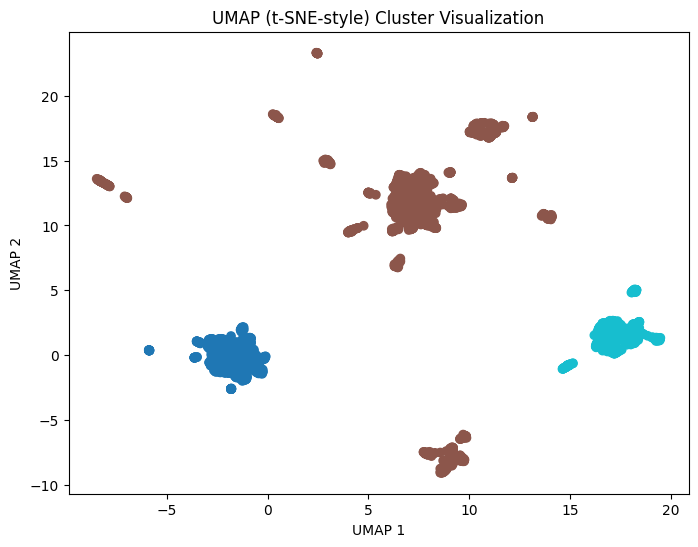

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Clustered data saved to clustered_hinglish_data_bert_rules_3_clusters.csv and downloaded.


In [ ]:
# 📊 Visualization

reducer = umap.UMAP(n_components=2, random_state=42)
umap_reduced = reducer.fit_transform(X_combined)
plt.figure(figsize=(8, 6))
plt.scatter(umap_reduced[:, 0], umap_reduced[:, 1], c=df['cluster'], cmap='tab10')
plt.title("UMAP (t-SNE-style) Cluster Visualization")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

# Save CSV
output_filename = f"clustered_hinglish_data_bert_rules_{num_clusters}_clusters.csv"
df.to_csv(output_filename, index=False)
files.download(output_filename)
print(f"\n✅ Clustered data saved to {output_filename} and downloaded.")


In [ ]:
print("\nCluster Sizes:")
print(df['cluster'].value_counts())



Cluster Sizes:
cluster
1    2206
0    1008
2     786
Name: count, dtype: int64


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


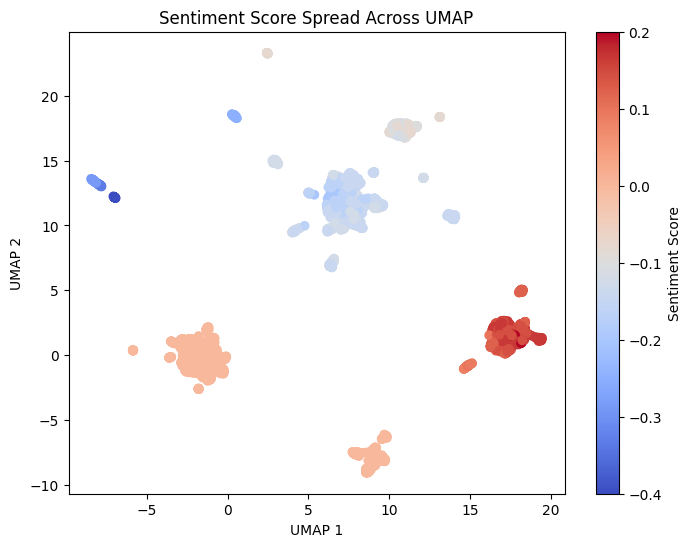

In [ ]:
from umap import UMAP

# Assuming X_combined is the combined feature set (e.g., embeddings + any other features)
reducer = UMAP(n_components=2, random_state=42)
reduced_umap = reducer.fit_transform(X_combined)  # Perform UMAP to reduce to 2 components
plt.figure(figsize=(8, 6))
plt.scatter(reduced_umap[:, 0], reduced_umap[:, 1], c=df['sentiment_score'], cmap='coolwarm')
plt.colorbar(label="Sentiment Score")
plt.title("Sentiment Score Spread Across UMAP")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()


📥 Upload your synthetic_hinglish_dataset_400.csv file:


Saving synthetic_hinglish_dataset_400.csv to synthetic_hinglish_dataset_400.csv


Batches:   0%|          | 0/13 [00:00<?, ?it/s]


📊 Evaluation Results on Synthetic Data (BERT + Rule Model):
✅ Accuracy:  0.88
✅ Precision: 0.91
✅ Recall:    0.88
✅ F1 Score:  0.87


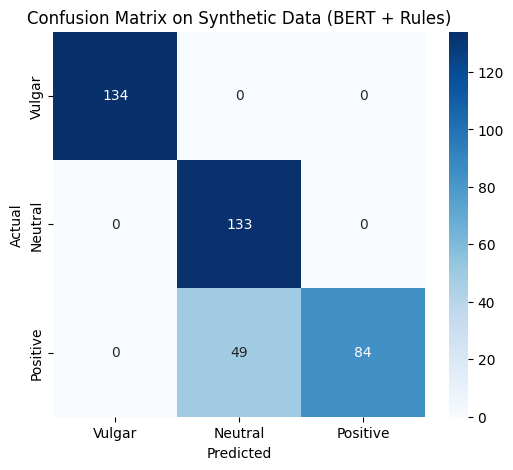


📌 Cluster → Label Mapping (based on sentiment score):
Cluster 1 → Vulgar
Cluster 0 → Neutral
Cluster 2 → Positive


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# 📥 Upload synthetic data
print("📥 Upload your synthetic_hinglish_dataset_400.csv file:")
uploaded_syn = files.upload()
synthetic_df = pd.read_csv(list(uploaded_syn.keys())[0])

# 🧹 Preprocess
synthetic_df['clean'] = synthetic_df['text'].apply(preprocess_text)

# 🔎 Embed using the same BERT model
X_syn_embed = bert_model.encode(synthetic_df['clean'], show_progress_bar=True)

# 🔧 Rule-based features
synthetic_df['vulgar_flag'] = synthetic_df['clean'].apply(contains_vulgar)
synthetic_df['sentiment_score'] = synthetic_df['clean'].apply(get_sentiment_score)

# 🔄 Scale and combine
extra_syn = synthetic_df[['vulgar_flag', 'sentiment_score']].astype(float).values
scaled_syn = StandardScaler().fit_transform(extra_syn)
X_syn_combined = np.hstack([X_syn_embed, scaled_syn])

# 🔁 Predict cluster
synthetic_df['pred_cluster'] = kmeans.predict(X_syn_combined)

# 🧠 Map clusters → labels based on training cluster avg sentiment
sorted_clusters = sorted(cluster_info.items(), key=lambda x: x[1]['avg_sentiment'])
cluster_to_label = {
    sorted_clusters[0][0]: 0,  # Vulgar
    sorted_clusters[1][0]: 1,  # Neutral
    sorted_clusters[2][0]: 2   # Positive
}
synthetic_df['pred_label'] = synthetic_df['pred_cluster'].map(cluster_to_label)

# 🎯 Evaluation
y_true = synthetic_df['label']
y_pred = synthetic_df['pred_label']

print("\n📊 Evaluation Results on Synthetic Data (BERT + Rule Model):")
print(f"✅ Accuracy:  {accuracy_score(y_true, y_pred):.2f}")
print(f"✅ Precision: {precision_score(y_true, y_pred, average='weighted'):.2f}")
print(f"✅ Recall:    {recall_score(y_true, y_pred, average='weighted'):.2f}")
print(f"✅ F1 Score:  {f1_score(y_true, y_pred, average='weighted'):.2f}")

# 📉 Confusion Matrix
conf_mat = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Vulgar', 'Neutral', 'Positive'],
            yticklabels=['Vulgar', 'Neutral', 'Positive'])
plt.title("Confusion Matrix on Synthetic Data (BERT + Rules)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 🔍 Show cluster-to-label mapping
print("\n📌 Cluster → Label Mapping (based on sentiment score):")
for k, v in cluster_to_label.items():
    print(f"Cluster {k} → {['Vulgar', 'Neutral', 'Positive'][v]}")


Cluster Composition Pie Chart: Get a proportion view of data types across clusters.

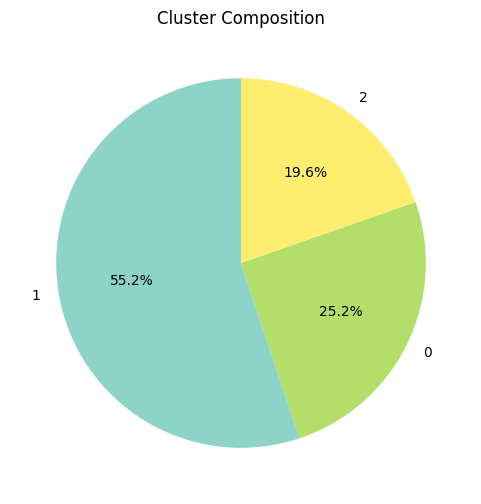

In [ ]:
cluster_sizes = df['cluster'].value_counts()
cluster_sizes.plot.pie(autopct='%1.1f%%', startangle=90, cmap='Set3', figsize=(6,6))
plt.title("Cluster Composition")
plt.ylabel('')
plt.show()


Vulgarity HeatMap : Show how vulgar terms are distributed.

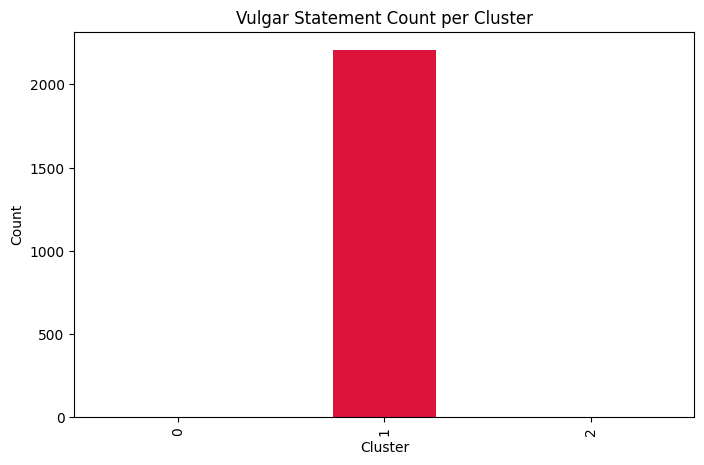

In [ ]:
vulgarity_counts = df.groupby('cluster')['vulgar_flag'].sum()

plt.figure(figsize=(8, 5))
vulgarity_counts.plot(kind='bar', color='crimson')
plt.title('Vulgar Statement Count per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()


Sentiment Distribution Per Cluster: Purpose: Show how sentiment varies per cluster.


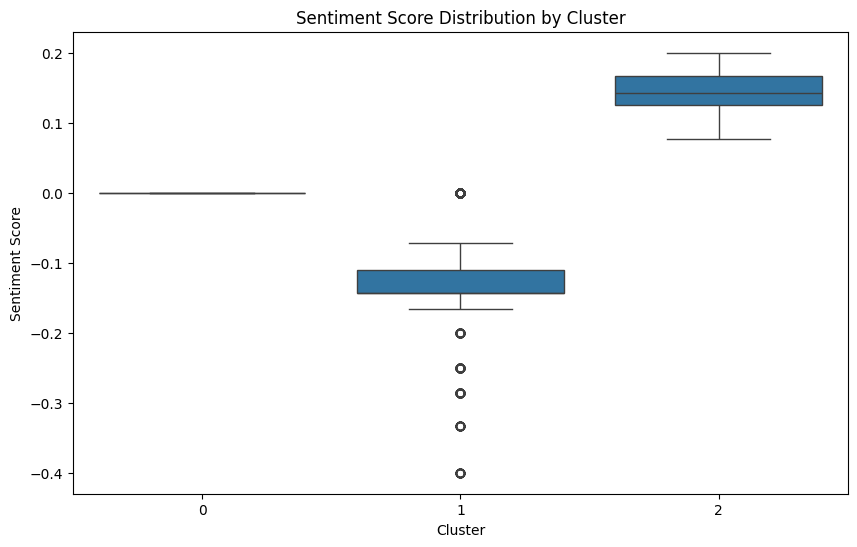

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='sentiment_score', data=df)
plt.title('Sentiment Score Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Sentiment Score')
plt.show()
